In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the uploaded dataset (exact path you uploaded)
df = pd.read_csv("/content/drive/MyDrive/spam.csv", encoding="latin-1")

# Keep only needed columns and rename
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Show first 5 rows and shape
print(df.shape)
df.head()


(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import nltk
import re
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # keep only letters
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

# Apply cleaning
df['clean_message'] = df['message'].apply(clean_text)

df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_message'])
y = df['label']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)


MultinomialNB(alpha=0.1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred, pos_label='spam'))
print("F1 Score:", f1_score(y_test, y_pred, pos_label='spam'))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9713004484304932
Precision: 0.8511904761904762
Recall: 0.9533333333333334
F1 Score: 0.89937106918239

Confusion Matrix:
 [[940  25]
 [  7 143]]

Classification Report:
               precision    recall  f1-score   support

         ham       0.99      0.97      0.98       965
        spam       0.85      0.95      0.90       150

    accuracy                           0.97      1115
   macro avg       0.92      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115



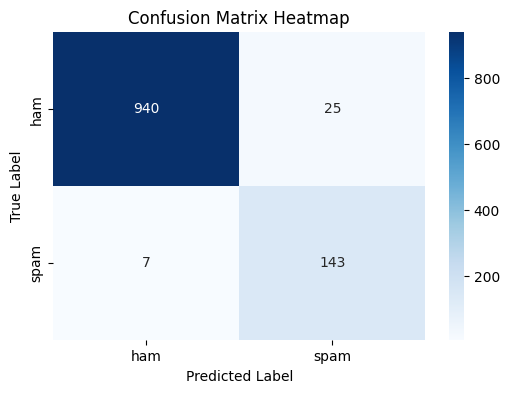

In [ ]:
# Visual Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [ ]:
def predict_message(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    return "Spam" if prediction == "spam" else "Ham"

samples = [
    "Congratulations! You've won a free lottery. Claim now.",
    "Are you coming to office today?",
    "Free vacation offer only for you!"
]

for msg in samples:
    print("Message:", msg)
    print("Prediction:", predict_message(msg))
    print("-" * 40)


Message: Congratulations! You've won a free lottery. Claim now.
Prediction: Spam
----------------------------------------
Message: Are you coming to office today?
Prediction: Ham
----------------------------------------
Message: Free vacation offer only for you!
Prediction: Spam
----------------------------------------
